In [9]:
import pandas as pd
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer 
from sklearn.compose import ColumnTransformer

In [10]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [11]:
df.sample(5)

,Survived,Age,Fare
238,0,19.0,10.500
277,0,NaN,0.000
80,0,22.0,9.000
379,0,19.0,7.775
143,0,19.0,6.750


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [13]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [19]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\suhav\AppData\Local\Temp\ipykernel_5412\694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [21]:
X=df.iloc[:,1:3]
y=df.iloc[:,0]

In [22]:
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)

C:\Users\suhav\AppData\Local\Temp\ipykernel_5412\3068769755.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


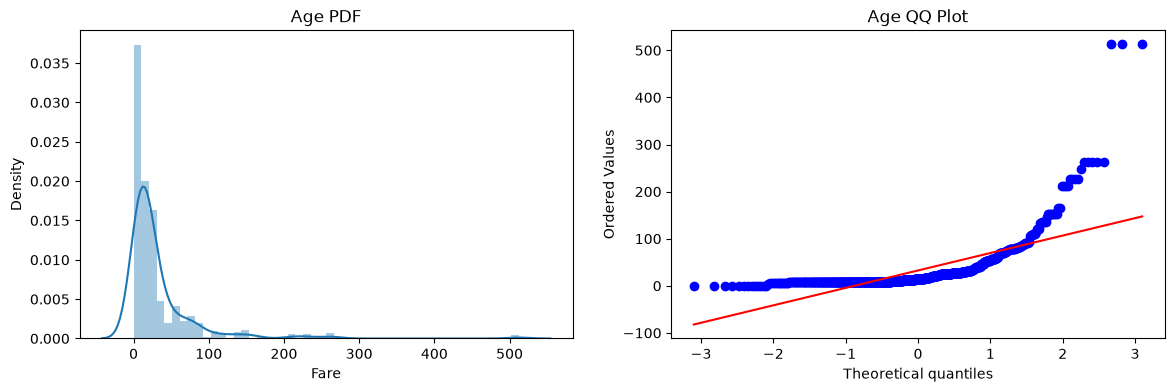

In [23]:
plt.figure(figsize=(14,4))

plt.subplot(121)

sns.distplot(X_train['Fare'])

plt.title('Age PDF')

plt.subplot(122)

stats.probplot(X_train ['Fare'], dist="norm", plot=plt)

plt.title('Age QQ Plot')

plt.show()

In [25]:
clf= LogisticRegression()

clf2= DecisionTreeClassifier()

In [29]:
clf.fit(X_train, y_train)

clf2.fit(X_train,y_train)

y_pred =clf.predict(X_test) 
y_pred1 =clf2.predict(X_test)

print("Accuracy LR", accuracy_score(y_test,y_pred)) 
print("Accuracy DT", accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.659217877094972


In [33]:
trf =FunctionTransformer(func=np.log1p)  #log1p mean s x->x+1 to handle 0 

In [35]:

X_train_transformed= trf.fit_transform(X_train)

X_test_transformed =trf.transform(X_test)

In [42]:
clf =LogisticRegression() 
c1f2 =DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train) 
clf2.fit(X_train_transformed,y_train)

y_pred =clf.predict(X_test_transformed)
y_pred1 =clf2.predict(X_test_transformed)

print("Accuracy LR", accuracy_score(y_test,y_pred))
print("Accuracy DT" ,accuracy_score(y_test ,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6815642458100558


In [44]:
X_transformed=trf.fit_transform(X)
clf =LogisticRegression()
clf2 =DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf,X_transformed, y, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(c1f2,X_transformed, y, scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6599999999999999


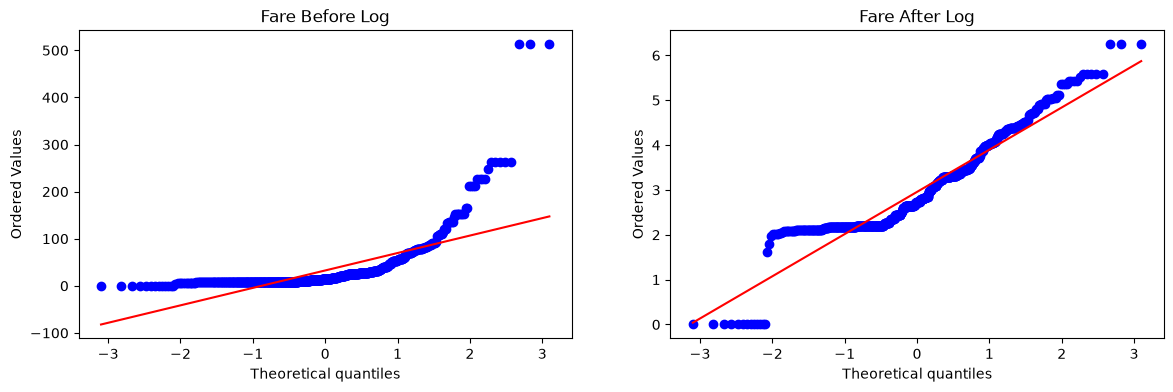

In [47]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train ['Fare'], dist="norm", plot=plt) 
plt.title('Fare Before Log')
plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt) 
plt.title('Fare After Log')
plt.show()

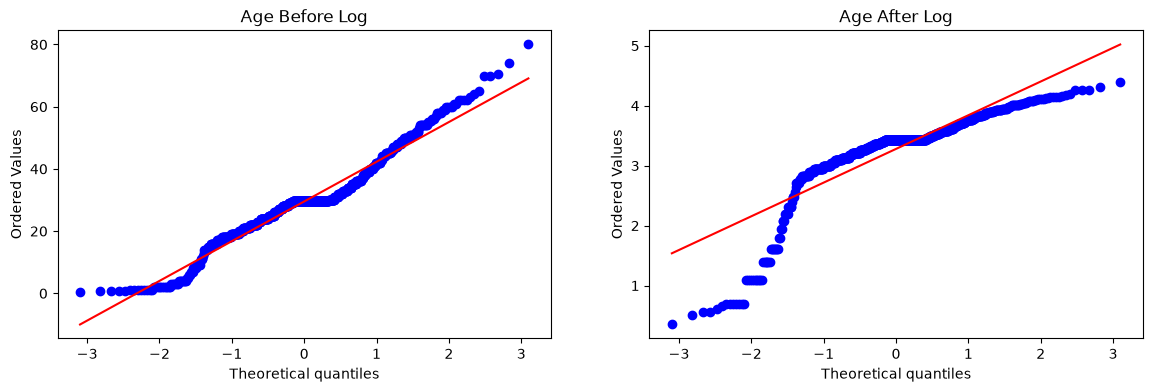

In [48]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train ['Age'], dist="norm", plot=plt) 
plt.title('Age Before Log')
plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt) 
plt.title('Age After Log')
plt.show()

In [55]:
trf2 =ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])], remainder='passthrough')
X_train_transformed2=trf2.fit_transform(X_train)
X_test_transformed2=trf2.transform(X_test)

In [56]:
clf =LogisticRegression() 
c1f2 =DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train) 
clf2.fit(X_train_transformed2,y_train)

y_pred =clf.predict(X_test_transformed2)
y_pred1 =clf2.predict(X_test_transformed2)

print("Accuracy LR", accuracy_score(y_test,y_pred))
print("Accuracy DT" ,accuracy_score(y_test ,y_pred1))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6703910614525139


In [57]:
X_transformed2=trf2.fit_transform(X)
clf =LogisticRegression()
clf2 =DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf,X_transformed2, y, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(c1f2,X_transformed2, y, scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6588514357053683


In [58]:
# dt no diff but lr pe pade when we do log on fare only and not on age

In [72]:
def apply_transform(transform):
    X=df.iloc[:,1:3]
    y=df.iloc[:,0]
    
    trf= ColumnTransformer([('log', FunctionTransformer(transform), ['Fare'])], remainder= 'passthrough')
    
    X_trans =trf.fit_transform(X)
    
    clf =LogisticRegression()
    
    print("Accuracy", np.mean(cross_val_score(clf, X_trans, y, scoring ='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))
    
    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot= plt) 
    plt.title('Fare Before Transform')
    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6431335830212235


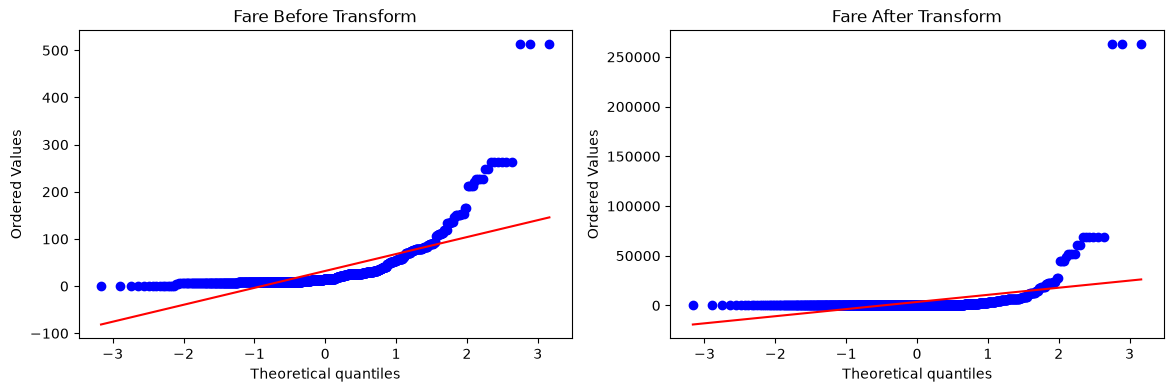

In [73]:
apply_transform(lambda x:x**2)